Data organized as a Numpy matrix where each row corresponds to an observation or as list of lists:

In [1]:
data = [[ 0.80,  0.55,  0.22,  0.03],
        [ 0.82,  0.50,  0.23,  0.03],
        [ 0.80,  0.54,  0.22,  0.03],
        [ 0.80,  0.53,  0.26,  0.03],
        [ 0.79,  0.56,  0.22,  0.03],
        [ 0.75,  0.60,  0.25,  0.03],
        [ 0.77,  0.59,  0.22,  0.03]]      

Train MiniSom:

In [2]:
from minisom import MiniSom    
som = MiniSom(6, 6, 4, sigma=0.3, learning_rate=0.5) # initialization of 6x6 SOM
som.train(data, 100) # trains the SOM with 100 iterations

Obtain the position of the winning neuron on the map:

In [3]:
som.winner(data[0])

(3, 4)

Other example:

In [4]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
  # Install Intrasom
  !pip install minisom

LOCAL_DEV = False
if LOCAL_DEV:
    sys.path.insert(0, '../')
    %load_ext autoreload


In [5]:
from minisom import MiniSom
import pandas as pd
import numpy as np
columns=['area', 'perimeter', 'compactness', 'length_kernel', 'width_kernel',
                   'asymmetry_coefficient', 'length_kernel_groove', 'target']
data = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt', 
                    names=columns, 
                   sep='\t+', engine='python')
target = data['target'].values

#print(target)
label_names = {1:'Kama', 2:'Rosa', 3:'Canadian'}
data = data[data.columns[:-1]]
# data normalization
data = (data - np.mean(data, axis=0)) / np.std(data, axis=0)
data = data.values

In [6]:
# Initialization and training
n_neurons = 9
m_neurons = 9

som = MiniSom(n_neurons, m_neurons, data.shape[1], sigma=1.5, learning_rate=.5, 
              neighborhood_function='gaussian', random_seed=0, topology='rectangular')

som.pca_weights_init(data)
som.train(data, 1000, verbose=True)  # random training

 [ 1000 / 1000 ] 100% - 0:00:00 left 
 quantization error: 0.506671895909233


C:\Users\abril\anaconda3\lib\site-packages\minisom.py:388: ComplexWarning: Casting complex values to real discards the imaginary part
  self._weights[i, j] = c1*pc[pc_order[0]] + \


In [7]:
som.topographic_error(data[:100])

0.08

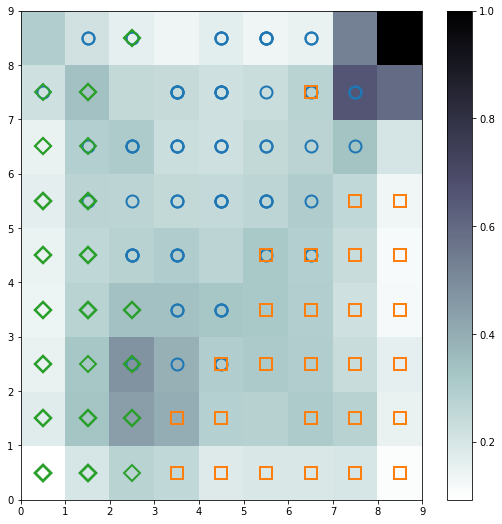

In [8]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(9, 9))

plt.pcolor(som.distance_map().T, cmap='bone_r')  # plotting the distance map as background
plt.colorbar()

# Plotting the response for each pattern in the iris dataset
# different colors and markers for each label
markers = ['o', 's', 'D']
colors = ['C0', 'C1', 'C2']
for cnt, xx in enumerate(data):
    w = som.winner(xx)  # getting the winner
    # palce a marker on the winning position for the sample xx
    plt.plot(w[0]+.5, w[1]+.5, markers[target[cnt]-1], markerfacecolor='None',
             markeredgecolor=colors[target[cnt]-1], markersize=12, markeredgewidth=2)

plt.show()

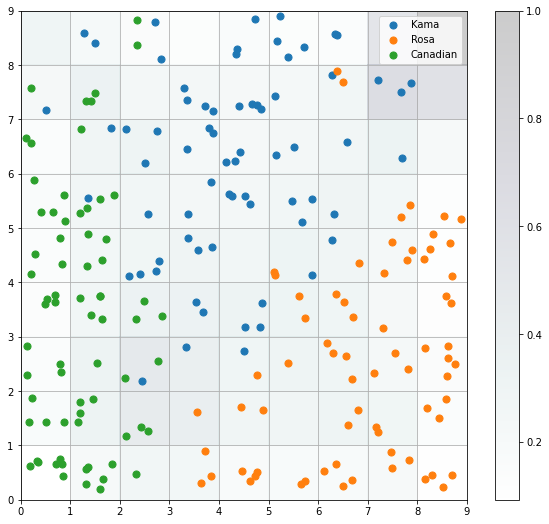

In [9]:


w_x, w_y = zip(*[som.winner(d) for d in data])
w_x = np.array(w_x)
w_y = np.array(w_y)

plt.figure(figsize=(10, 9))
plt.pcolor(som.distance_map().T, cmap='bone_r', alpha=.2)
plt.colorbar()

for c in np.unique(target):
    idx_target = target==c
    plt.scatter(w_x[idx_target]+.5+(np.random.rand(np.sum(idx_target))-.5)*.8,
                w_y[idx_target]+.5+(np.random.rand(np.sum(idx_target))-.5)*.8, 
                s=50, c=colors[c-1], label=label_names[c])
plt.legend(loc='upper right')
plt.grid()
plt.show()



In [1]:
from minisom import MiniSom
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
columns = ['Key','RShoulderPitch', 'RShoulderRoll', 'RElbowYaw', 'RElbowRoll']
data = pd.read_csv('motor_angles.csv', names=columns, sep=',', engine='python')


target = data['Key'].values

#print(target)
# Remove first column 
data = data[data.columns[1:]]
#print(data)
# Data normalization
data = (data - np.mean(data, axis=0)) / np.std(data, axis=0)
data = data.values

# Initialization and training
n_neurons = 5
m_neurons = 5

somAngles = MiniSom(n_neurons, m_neurons, data.shape[1], sigma=1.5, learning_rate=.5, 
              neighborhood_function='gaussian', random_seed=0, topology='rectangular')

somAngles.pca_weights_init(data)
somAngles.train(data, 1000, verbose=True)  # random training


 [ 1000 / 1000 ] 100% - 0:00:00 left 
 quantization error: 0.8343984187591065


C:\Users\abril\anaconda3\lib\site-packages\minisom.py:388: ComplexWarning: Casting complex values to real discards the imaginary part
  self._weights[i, j] = c1*pc[pc_order[0]] + \


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


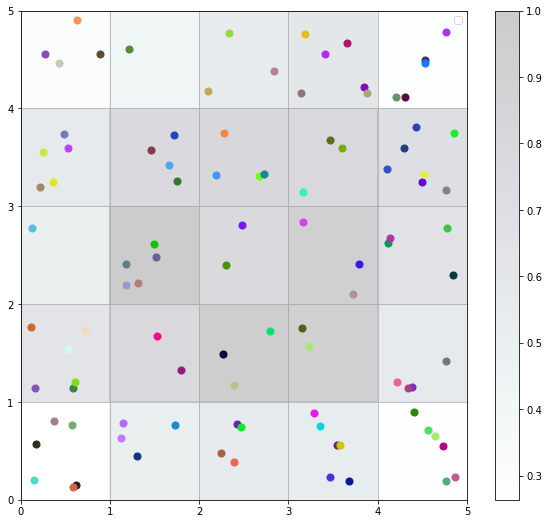

In [2]:
import random 

# Generate label names
label_names = {i: f'Key_{i}' for i in range(0, 100)}

# Generate random colors
colors = ['#' + ''.join(random.choices('0123456789ABCDEF', k=6)) for _ in range(100)]

#plot som
w_x, w_y = zip(*[somAngles.winner(d) for d in data])
w_x = np.array(w_x)
w_y = np.array(w_y)

plt.figure(figsize=(10, 9))
plt.pcolor(somAngles.distance_map().T, cmap='bone_r', alpha=.2)
plt.colorbar()

for c in np.unique(target):
    idx_target = target==c
    plt.scatter(w_x[idx_target]+.5+(np.random.rand(np.sum(idx_target))-.5)*.8,
                w_y[idx_target]+.5+(np.random.rand(np.sum(idx_target))-.5)*.8, 
                s=50, c=colors[c-1])
    #, label=label_names[c]
plt.legend(loc='upper right')
plt.grid()
plt.show()


In [3]:
from minisom import MiniSom
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
columns = ['Key','X', 'Y', 'Z']
data = pd.read_csv('gps_hand.csv', names=columns, sep=',', engine='python')


target = data['Key'].values

#print(target)
# Remove first column 
data = data[data.columns[1:]]
#print(data)
# Data normalization
data = (data - np.mean(data, axis=0)) / np.std(data, axis=0)
data = data.values

# Initialization and training
n_neurons = 5
m_neurons = 5

somVisual = MiniSom(n_neurons, m_neurons, data.shape[1], sigma=1.5, learning_rate=.5, 
              neighborhood_function='gaussian', random_seed=0, topology='rectangular')

somVisual.pca_weights_init(data)
somVisual.train(data, 1000, verbose=True)  # random training


 [ 1000 / 1000 ] 100% - 0:00:00 left 
 quantization error: 0.46850250072100535


C:\Users\abril\anaconda3\lib\site-packages\minisom.py:388: ComplexWarning: Casting complex values to real discards the imaginary part
  self._weights[i, j] = c1*pc[pc_order[0]] + \


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


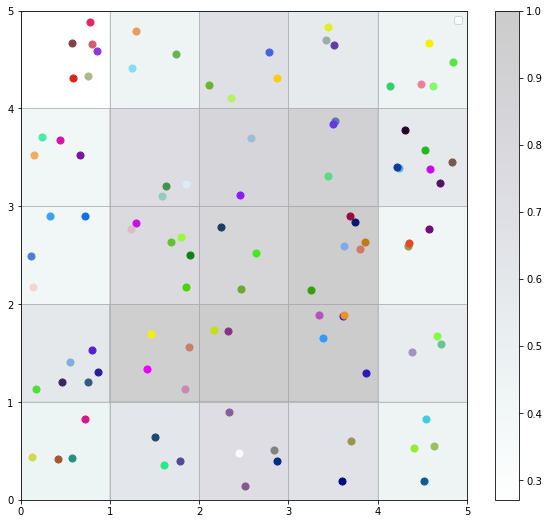

In [4]:
import random 

# Generate label names
label_names = {i: f'Key_{i}' for i in range(0, 100)}

# Generate random colors
colors = ['#' + ''.join(random.choices('0123456789ABCDEF', k=6)) for _ in range(100)]

#plot som
w_x, w_y = zip(*[somVisual.winner(d) for d in data])
w_x = np.array(w_x)
w_y = np.array(w_y)

plt.figure(figsize=(10, 9))
plt.pcolor(somVisual.distance_map().T, cmap='bone_r', alpha=.2)
plt.colorbar()

for c in np.unique(target):
    idx_target = target==c
    plt.scatter(w_x[idx_target]+.5+(np.random.rand(np.sum(idx_target))-.5)*.8,
                w_y[idx_target]+.5+(np.random.rand(np.sum(idx_target))-.5)*.8, 
                s=50, c=colors[c-1])
    #, label=label_names[c]
plt.legend(loc='upper right')
plt.grid()
plt.show()

In [5]:
import pickle
with open('somAngles.p', 'wb') as outfile:
    pickle.dump(somAngles, outfile)

In [6]:
import pickle
with open('somVisual.p', 'wb') as outfile:
    pickle.dump(somAngles, outfile)